Fused Softmax tutorial is based on https://triton-lang.org/main/getting-started/tutorials/02-fused-softmax.html under MIT license.


# Fused Softmax

In this tutorial, you will write a fused softmax operation that is significantly faster
than PyTorch's native op for a particular class of matrices: **those whose rows can fit in
the GPU's SRAM**.

In doing so, you will learn about:

* The benefits of kernel fusion for bandwidth-bound operations.

* Reduction operators in Triton.


In [1]:
import torch

import triton
import triton.language as tl
from triton.runtime import driver

DEVICE = triton.runtime.driver.active.get_active_torch_device()

## Strides

Given a linear memory layout of N dimensional tensor, a stride defines number of elements that we have to skip in orther to advance one position in given direction - an offset between indices.

In [2]:
v = torch.ones((2,3,4))
print("Tensor: ", v)
print("Shape: ", v.shape)
print("Strides: ", v.stride())

Tensor:  tensor([[[1., 1., 1., 1.],
         [1., 1., 1., 1.],
         [1., 1., 1., 1.]],

        [[1., 1., 1., 1.],
         [1., 1., 1., 1.],
         [1., 1., 1., 1.]]])
Shape:  torch.Size([2, 3, 4])
Strides:  (12, 4, 1)


## Motivations

Let us consider the case of a simple softmax operation converts a tuple of K real numbers into a probability distribution over K possible outcomes.

$$\sigma(\mathbf{x})_i = \frac{e^{x_i}}{\sum^K_j e^{x_j}};\quad \sigma(\mathbf{x})\in(0,1)^K$$

To calculate softmax we will need to calculate value of `exp` for each element, perform reduction by calculating the `sum` and finaly perform division to normalyze. In addition it is beneficial to substract maximum value from each element to improve numerical stability.

Calculating it as separate torch operations will incure multiple round trips between GPU DRAM and SRAM affecting performance.

Let us consider a case with 2D data: $x \in R^{M \times N}$. Such pattern is often encountered for ML classificator using one-hot-encoding for N classes and M samples.


In [3]:
def naive_softmax(x):
    """Compute row-wise softmax of X using native pytorch

    We subtract the maximum element in order to avoid overflows. Softmax is invariant to
    this shift.
    """
    # read  MN elements ; write M  elements
    x_max = x.max(dim=1)[0]
    # read MN + M elements ; write MN elements
    z = x - x_max[:, None]
    # read  MN elements ; write MN elements
    numerator = torch.exp(z)
    # read  MN elements ; write M  elements
    denominator = numerator.sum(dim=1)
    # read MN + M elements ; write MN elements
    ret = numerator / denominator[:, None]
    # in total: read 5MN + 2M elements ; wrote 3MN + 2M elements
    return ret

@torch.jit.script
def naive_softmax_jit(x):
    return naive_softmax(x)

When implemented naively in PyTorch, computing `y = naive_softmax(x)` for $x \in R^{M \times N}$
requires reading $5MN + 2M$ elements from DRAM and writing back $3MN + 2M$ elements.
This is obviously wasteful; we'd prefer to have a custom "fused" kernel that only reads
X once and does all the necessary computations on-chip.

Doing so would require reading and writing back only $MN$ elements, so we could
expect a theoretical speed-up of ~4x (i.e., $(8MN + 4M) / 2MN$).

The `torch.jit.script` flags aims to perform this kind of "kernel fusion" automatically
but, as we will see later, it is still far from ideal.

**For Torch 2.0 or newer use `torch.compile`: https://docs.pytorch.org/tutorials/intermediate/torch_compile_tutorial.html**

Primarily, the advantage of `torch.compile` over `torch.script` lies in its ability to handle arbitrary Python code with minimal changes to existing code.

## Compute Kernel

We will use `triton.jit` decorator to define a triton program: https://triton-lang.org/main/python-api/generated/triton.jit.html#triton.jit

Keep in mind that Triton compute kernels operate on blocks of memory that must have power-of-two number of elements.

Our softmax kernel works as follows:
* each program calculates the pointer offset to the memory block to porcess,
* loads a set of rows of the input matrix `X` strided by number of programs,
* calculates values of `exp` and normalisation using data loaded to SRAM,
* calculates the pointer offset to the outout memory block,
* writes back the result to the output `Y`.

Note that one important limitation of Triton is that each block must have a
power-of-two number of elements, so we need to internally "pad" each row and guard the
memory operations properly if we want to handle any possible input shapes.



In [4]:
@triton.jit
def softmax_kernel(output_ptr, input_ptr, input_row_stride, output_row_stride, n_rows, n_cols, BLOCK_SIZE: tl.constexpr,
                   num_stages: tl.constexpr):
    # starting row of the program
    row_start = tl.program_id(0)
    row_step = tl.num_programs(0)
    for row_idx in tl.range(row_start, n_rows, row_step, num_stages=num_stages):
        # The stride represents how much we need to increase the pointer to advance 1 row
        row_start_ptr = input_ptr + row_idx * input_row_stride
        # The block size is the next power of two greater than n_cols, so we can fit each
        # row in a single block
        col_offsets = tl.arange(0, BLOCK_SIZE)
        input_ptrs = row_start_ptr + col_offsets
        # Load the row into SRAM, using a mask since BLOCK_SIZE may be > than n_cols
        mask = col_offsets < n_cols
        row = tl.load(input_ptrs, mask=mask, other=-float('inf'))
        # Subtract maximum for numerical stability
        row_minus_max = row - tl.max(row, axis=0)
        # Note that exponentiation in Triton is fast but approximate (i.e., think __expf in CUDA)
        numerator = tl.exp(row_minus_max)
        denominator = tl.sum(numerator, axis=0)
        softmax_output = numerator / denominator
        # Write back output to DRAM
        output_row_start_ptr = output_ptr + row_idx * output_row_stride
        output_ptrs = output_row_start_ptr + col_offsets
        tl.store(output_ptrs, softmax_output, mask=mask)

We can create a helper function that enqueues the kernel and its (meta-)arguments for any given input tensor.



In [5]:
# Determine device properties
properties = driver.active.utils.get_device_properties(DEVICE.index)
NUM_SM = properties["multiprocessor_count"]
NUM_REGS = properties["max_num_regs"]
SIZE_SMEM = properties["max_shared_mem"]
WARP_SIZE = properties["warpSize"]
target = triton.runtime.driver.active.get_current_target()
kernels = {}


def softmax(x):
    n_rows, n_cols = x.shape

    # The block size of each loop iteration is the smallest power of two greater than the number of columns in `x`
    BLOCK_SIZE = triton.next_power_of_2(n_cols)

    # Another trick we can use is to ask the compiler to use more threads per row by
    # increasing the number of warps (`num_warps`) over which each row is distributed.
    # You will see in the next tutorial how to auto-tune this value in a more natural
    # way so you don't have to come up with manual heuristics yourself.
    num_warps = 8

    # Number of software pipelining stages.
    num_stages = 4 if SIZE_SMEM > 200000 else 2

    # Allocate output
    y = torch.empty_like(x)

    # pre-compile kernel to get register usage and compute thread occupancy.
    kernel = softmax_kernel.warmup(y, x, x.stride(0), y.stride(0), n_rows, n_cols, BLOCK_SIZE=BLOCK_SIZE,
                                   num_stages=num_stages, num_warps=num_warps, grid=(1, ))
    kernel._init_handles()
    n_regs = kernel.n_regs
    size_smem = kernel.metadata.shared
    occupancy = NUM_REGS // (n_regs * WARP_SIZE * num_warps)
    occupancy = min(occupancy, SIZE_SMEM // size_smem)
    num_programs = NUM_SM * occupancy

    num_programs = min(num_programs, n_rows)

    # Create a number of persistent programs.
    kernel[(num_programs, 1, 1)](y, x, x.stride(0), y.stride(0), n_rows, n_cols, BLOCK_SIZE, num_stages)
    return y

## Unit Test



We make sure that we test our kernel on a matrix with an irregular number of rows and columns.
This will allow us to verify that our padding mechanism works.



In [8]:
torch.manual_seed(0)
x = torch.randn(1823, 781, device=DEVICE)
y_triton = softmax(x)
y_torch = torch.softmax(x, axis=1)
assert torch.allclose(y_triton, y_torch), (y_triton, y_torch)

As expected, the results are identical.



## Benchmark

Here we will benchmark our operation as a function of the number of columns in the input matrix -- assuming 4096 rows.
We will then compare its performance against (1) `torch.softmax` and (2) the `naive_softmax` defined above.



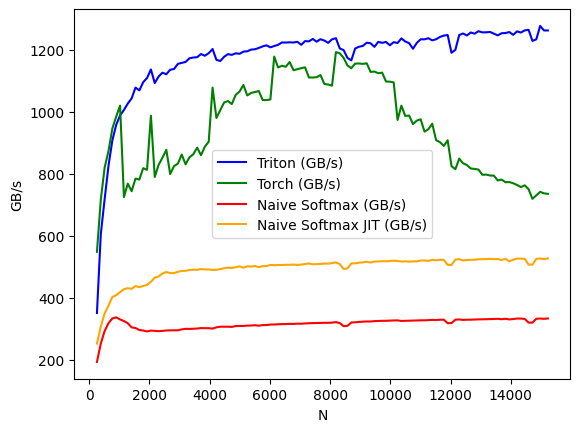

softmax-performance:
           N  Triton (GB/s)  Torch (GB/s)  Naive Softmax (GB/s)  Naive Softmax JIT (GB/s)
0      256.0     351.396487    548.698764            193.567846                252.790747
1      384.0     605.856067    716.611948            252.796233                307.646510
2      512.0     718.952560    820.582132            293.555074                350.401467
3      640.0     826.518825    873.841019            318.753374                375.050425
4      768.0     908.294899    946.473224            333.741582                403.245537
5      896.0     958.294618    984.795694            337.357583                408.767633
6     1024.0     988.377626   1020.241589            330.548682                418.580914
7     1152.0    1005.973418    725.249132            325.445715                428.037634
8     1280.0    1026.685134    768.551536            318.379817                431.375130
9     1408.0    1043.261080    744.020838            304.943721                

In [ ]:
@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=['N'],  # argument names to use as an x-axis for the plot
        x_vals=[128 * i for i in range(2, 120)],  # different possible values for `x_name`
        line_arg='provider',  # argument name whose value corresponds to a different line in the plot
        line_vals=['triton', 'torch', 'naive_softmax', 'naive_softmax_jit'],  # possible values for `line_arg``
        line_names=["Triton", "Torch", "Naive Softmax", "Naive Softmax JIT"],  # label name for the lines
        styles=[('blue', '-'), ('green', '-'), ('red', '-'), ('orange', '-')],  # line styles
        ylabel="GB/s",  # label name for the y-axis
        plot_name="softmax-performance",  # name for the plot. Used also as a file name for saving the plot.
        args={'M': 4096},  # values for function arguments not in `x_names` and `y_name`
    ))
def benchmark(M, N, provider):
    x = torch.randn(M, N, device=DEVICE, dtype=torch.float32)

    if provider == 'torch':
        ms = triton.testing.do_bench(lambda: torch.softmax(x, axis=-1))
    if provider == 'triton':
        ms = triton.testing.do_bench(lambda: softmax(x))
    if provider == 'naive_softmax':
        ms = triton.testing.do_bench(lambda: naive_softmax(x))
    if provider == 'naive_softmax_jit':
        ms = triton.testing.do_bench(lambda: naive_softmax_jit(x))
    gbps = lambda ms: 2 * x.numel() * x.element_size() * 1e-9 / (ms * 1e-3)
    return gbps(ms)


benchmark.run(show_plots=True, print_data=True)

In the above plot, we can see that:
 - Triton is 4x faster than the Torch JIT. This confirms our suspicions that the Torch JIT does not do any fusion here.
 - Triton is noticeably faster than `torch.softmax` -- in addition to being **easier to read, understand and maintain**.
   Note however that the PyTorch `softmax` operation is more general and will work on tensors of any shape.



## Autotuning with `triton.autotune`

In the manual `softmax` wrapper above we hard-coded `num_warps=8` and chose `num_stages`
with a simple heuristic. In practice the optimal values depend on the GPU architecture
**and** the problem shape (row width). Triton provides `@triton.autotune` to search
over a set of configurations automatically.

### How it works

1. We define a list of `triton.Config` objects, each specifying `num_warps` and `num_stages`.
2. `@triton.autotune` wraps the kernel and, the first time it sees a new value of the
   `key` parameter(s), benchmarks every config and caches the winner.
3. Subsequent calls with the same key skip tuning and use the cached best config.

The `key` parameter tells autotune *when the optimal config might change*. We use
`BLOCK_SIZE` since it determines the workload per program and directly affects register
pressure and shared memory usage.

In [8]:
@triton.autotune(
    configs=[
        triton.Config({}, num_warps=w, num_stages=s)
        for w in [1, 2, 4, 8, 16, 32, 64]
        for s in [2, 3, 4, 8, 16]
    ],
    key=['BLOCK_SIZE'],
)
@triton.jit
def softmax_kernel_autotuned(
    output_ptr, input_ptr,
    input_row_stride, output_row_stride,
    n_rows, n_cols,
    BLOCK_SIZE: tl.constexpr,
):
    # Same logic as the manual kernel -- only num_warps/num_stages differ
    row_start = tl.program_id(0)
    row_step = tl.num_programs(0)
    for row_idx in tl.range(row_start, n_rows, row_step):
        row_start_ptr = input_ptr + row_idx * input_row_stride
        col_offsets = tl.arange(0, BLOCK_SIZE)
        input_ptrs = row_start_ptr + col_offsets
        mask = col_offsets < n_cols
        row = tl.load(input_ptrs, mask=mask, other=-float('inf'))
        row_minus_max = row - tl.max(row, axis=0)
        numerator = tl.exp(row_minus_max)
        denominator = tl.sum(numerator, axis=0)
        softmax_output = numerator / denominator
        output_row_start_ptr = output_ptr + row_idx * output_row_stride
        output_ptrs = output_row_start_ptr + col_offsets
        tl.store(output_ptrs, softmax_output, mask=mask)

Notice how much simpler the wrapper becomes -- no manual occupancy calculation, no warmup
step. Autotune handles the `num_warps` / `num_stages` selection, and we simply launch
one program per row.

In [9]:
def softmax_autotuned(x):
    n_rows, n_cols = x.shape
    BLOCK_SIZE = triton.next_power_of_2(n_cols)
    y = torch.empty_like(x)
    softmax_kernel_autotuned[(n_rows, )](
        y, x,
        x.stride(0), y.stride(0),
        n_rows, n_cols,
        BLOCK_SIZE=BLOCK_SIZE,
    )
    return y

### Unit Test

Verify the autotuned kernel matches `torch.softmax`. The first call triggers tuning
(you will see Triton benchmarking each config).

In [10]:
torch.manual_seed(0)
x = torch.randn(1823, 781, device=DEVICE)
y_auto = softmax_autotuned(x)
y_torch = torch.softmax(x, axis=1)
assert torch.allclose(y_auto, y_torch), (y_auto, y_torch)
print("Autotuned kernel matches torch.softmax: PASS")

Autotuned kernel matches torch.softmax: PASS


### Benchmark: Manual vs Autotuned

We compare three implementations:
- **Triton (manual)** -- hand-picked `num_warps=8`, heuristic `num_stages`
- **Triton (autotuned)** -- best config selected by `triton.autotune`
- **torch.softmax** -- PyTorch built-in

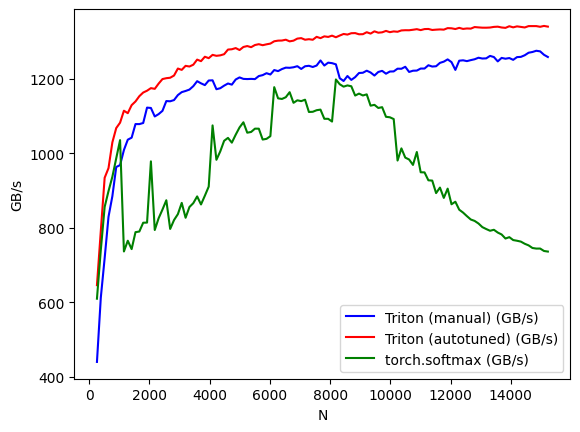

softmax-manual-vs-autotuned:
           N  Triton (manual) (GB/s)  Triton (autotuned) (GB/s)  torch.softmax (GB/s)
0      256.0              439.931738                 645.974154            609.637211
1      384.0              612.379994                 791.311755            740.359512
2      512.0              718.467793                 934.275226            856.055331
3      640.0              829.510820                 960.165083            898.406396
4      768.0              884.804011                1029.337246            936.943864
5      896.0              963.141480                1067.580526            986.379829
6     1024.0              968.275559                1082.140046           1035.273273
7     1152.0             1008.817339                1114.256966            736.399746
8     1280.0             1036.477401                1107.623056            765.266370
9     1408.0             1041.901241                1129.195466            742.782809
10    1536.0             

In [ ]:
@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=['N'],
        x_vals=[128 * i for i in range(2, 120)],
        line_arg='provider',
        line_vals=['triton_manual', 'triton_autotuned', 'torch'],
        line_names=['Triton (manual)', 'Triton (autotuned)', 'torch.softmax'],
        styles=[('blue', '-'), ('red', '-'), ('green', '-')],
        ylabel='GB/s',
        plot_name='softmax-manual-vs-autotuned',
        args={'M': 4096},
    )
)
def benchmark_autotune(M, N, provider):
    x = torch.randn(M, N, device=DEVICE, dtype=torch.float32)

    if provider == 'triton_manual':
        ms = triton.testing.do_bench(lambda: softmax(x))
    elif provider == 'triton_autotuned':
        ms = triton.testing.do_bench(lambda: softmax_autotuned(x))
    elif provider == 'torch':
        ms = triton.testing.do_bench(lambda: torch.softmax(x, axis=-1))
    gbps = 2 * x.numel() * x.element_size() * 1e-9 / (ms * 1e-3)
    return gbps


benchmark_autotune.run(show_plots=True, print_data=True)